# Final Code Notebook

This notebook will serve as the final evaluation file to consolidate and run all relevant models we have tested out and their corresponding metric results

## Initialisation

### Import statements

In [1]:
from pathlib import Path
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.model_selection import (
    train_test_split , StratifiedKFold, GridSearchCV, RandomizedSearchCV
)
# Classifiers
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_score, recall_score, f1_score, roc_curve, ConfusionMatrixDisplay
)

# NN imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# XGBoost
from xgboost import XGBClassifier

Suppressing Warnings from XGBoost run

In [2]:
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

### Defining Paths

In [3]:
# Get the current working directory as a Path object
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR.parent / 'data' / 'master_features.csv'

### Loading and cleaning Data

More specifically XGBoost requires clean column names

In [4]:
data = pd.read_csv(DATA_PATH)
data.columns = [
    re.sub(r'[\[\]<>()]', '', c).strip().replace('  ', ' ').replace(' ', '_')
    for c in data.columns
]
TARGET = "target_y"
TOP_FEATURES = [
    'macro_economic_pca_1', 'month_may', 'month_apr',
    'month_oct', 'contact_cellular', 'prior_engagement',
    'job_grouped_not_working'
]

X_all = data.drop(columns=[TARGET])
y     = data[TARGET]

### Train Test Split

In [5]:
random_state = 1244 # Set a fixed random state for reproducibility globally across all models
X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=random_state, stratify=y
)
X_train = X_train_all[TOP_FEATURES]
X_test  = X_test_all[TOP_FEATURES]

print(f"Dataset: {len(data):,} rows  |  Train: {len(y_train):,}  |  Test: {len(y_test):,}")
print(f"Positive rate — Train: {y_train.mean():.3f}  |  Test: {y_test.mean():.3f}\n")

Dataset: 41,188 rows  |  Train: 32,950  |  Test: 8,238
Positive rate — Train: 0.113  |  Test: 0.113



### Global Variables for Model Training

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

neg_prop, pos_prop = y_train.value_counts(normalize=True).sort_index()
class_weights = {0: 1 / neg_prop, 1: 1 / pos_prop}

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = neg_count / pos_count # For XGBoost's scale_pos_weight parameter

## 1. Logistic Regression

In [7]:
lr = LogisticRegression(class_weight=class_weights, random_state=1244)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

## 2. Decision Tree

In [8]:
dt_param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=random_state, class_weight=class_weights),
    param_grid=dt_param_grid,
    cv=cv,
    scoring='roc_auc'
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_
dt_pred = best_dt.predict(X_test)
dt_prob = best_dt.predict_proba(X_test)[:, 1]

print(f"Best params : {dt_grid.best_params_}")
print(f"Best CV AUC : {dt_grid.best_score_:.4f}")

Best params : {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 20}
Best CV AUC : 0.8033


## 3. Random Forest

In [9]:
rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 7, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_features': ['sqrt', 'log2']
}

n_iter = 30

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=random_state, class_weight=class_weights, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=n_iter,
    cv=cv,
    scoring='roc_auc'
)
rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
rf_pred = best_rf.predict(X_test)
rf_prob = best_rf.predict_proba(X_test)[:, 1]

print(f"Best params : {rf_search.best_params_}")
print(f"Best CV AUC : {rf_search.best_score_:.4f}")

Best params : {'n_estimators': 300, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 7}
Best CV AUC : 0.8019


## 4. XGBoost

In [10]:
print(f"scale_pos_weight (train only): {scale_pos:.4f}")

xgb_clf = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=1.0,
    colsample_bytree=1.0,
    objective='binary:logistic',    # binary → your target is binary (0 = Unsuccessful, 1 = Successful) 
                                    # logistic → use logistic regression as the underlying prediction model
                                    # The model outputs a probability between 0 and 1 (e.g., 0.73 = 73% chance of success)
                                    # Internally it minimises cross-entropy loss
    eval_metric='logloss',          # logloss (log loss) penalises confident wrong predictions more heavily than uncertain ones
                                    # A lower logloss = better model
    n_jobs=-1,
    random_state= random_state,
    scale_pos_weight=scale_pos  # ← Set the imbalance correction
    )

xgb_clf.fit(X_train_all, y_train)

xgb_pred = xgb_clf.predict(X_test_all)
xgb_prob = xgb_clf.predict_proba(X_test_all)[:, 1]

scale_pos_weight (train only): 7.8766


## 5. Neural Network
Neural Networks require a cyclical encoding to the months variables in order to account for the relative position of months

In [11]:
month_number_mapping = {'month_jan': 1, 'month_feb': 2, 'month_mar': 3, 'month_apr': 4,
                        'month_may': 5, 'month_jun': 6, 'month_jul': 7, 'month_aug': 8,
                        'month_sep': 9, 'month_oct': 10, 'month_nov': 11, 'month_dec': 12
                        }

def add_cyclical_month_encoding(df, month_col):
    month_num = month_number_mapping[month_col]
    df[f'{month_col}_sin'] = np.sin(2 * np.pi * month_num / 12)* df[month_col]
    df[f'{month_col}_cos'] = np.cos(2 * np.pi * month_num / 12)* df[month_col]
    df.drop(columns=[month_col], inplace=True)
    return df

def encode_months(top_features, X_train, X_test):
    X_train_final = X_train.copy()
    X_test_final = X_test.copy()
    months_to_encode = [col for col in top_features if col.startswith('month_')]
    for month_col in months_to_encode:
        X_train_final = add_cyclical_month_encoding(X_train_final, month_col)
        X_test_final = add_cyclical_month_encoding(X_test_final, month_col)
    return X_train_final, X_test_final

X_train_nn, X_test_nn = encode_months(TOP_FEATURES, X_train, X_test)

Building NN

In [12]:

from pyexpat import model


nn_model = keras.Sequential([
    keras.layers.Input(shape=(X_train_nn.shape[1],)),
    keras.layers.Dense(7, activation='relu'), # 2/3 of the number of features
    keras.layers.Dropout(0.2),
    keras.layers.Dense(7, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid') # Binary classification output
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[keras.metrics.AUC(name='auc')])

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
nn_model.fit(X_train_nn, y_train, 
                    validation_split=0.2, 
                    epochs=100, 
                    batch_size=32, 
                    class_weight=class_weights,
                    callbacks=[early_stopping])
nn_prob = nn_model.predict(X_test_nn, verbose=0).flatten()
nn_pred = (nn_prob > 0.5).astype(int)

Epoch 1/100


  1/824 ━━━━━━━━━━━━━━━━━━━━ 8:58 655ms/step - auc: 0.3304 - loss: 1.5164

131/824 ━━━━━━━━━━━━━━━━━━━━ 0s 386us/step - auc: 0.6091 - loss: 1.3070  

284/824 ━━━━━━━━━━━━━━━━━━━━ 0s 354us/step - auc: 0.6360 - loss: 1.3032

438/824 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step - auc: 0.6519 - loss: 1.3000

...

306/824 ━━━━━━━━━━━━━━━━━━━━ 0s 329us/step - auc: 0.7730 - loss: 1.1202

461/824 ━━━━━━━━━━━━━━━━━━━━ 0s 327us/step - auc: 0.7717 - loss: 1.1222

616/824 ━━━━━━━━━━━━━━━━━━━━ 0s 326us/step - auc: 0.7710 - loss: 1.1243

771/824 ━━━━━━━━━━━━━━━━━━━━ 0s 326us/step - auc: 0.7709 - loss: 1.1253

824/824 ━━━━━━━━━━━━━━━━━━━━ 0s 412us/step - auc: 0.7692 - loss: 1.1275 - val_auc: 0.8062 - val_loss: 0.5498


## Collate all results

In [13]:
def metrics(y_true, y_pred, y_prob):
    return {
        'Precision': round(float(precision_score(y_true, y_pred)), 4),
        'Recall':    round(float(recall_score(y_true, y_pred)),    4),
        'F1-Score':  round(float(f1_score(y_true, y_pred)),        4),
        'AUC-ROC':   round(float(roc_auc_score(y_true, y_prob)),   4),
        'y_pred':    y_pred,
        'y_prob':    y_prob,
    }

results = {
    'Logistic Regression': metrics(y_test, lr_pred,  lr_prob),
    'Decision Tree':       metrics(y_test, dt_pred,  dt_prob),
    'Random Forest':       metrics(y_test, rf_pred,  rf_prob),
    'XGBoost':             metrics(y_test, xgb_pred, xgb_prob),
    'Neural Network':      metrics(y_test, nn_pred,  nn_prob),
}

## Detailed Classification Report

In [14]:
for name, r in results.items():
    print(f"\n{'─' * 50}")
    print(f"  {name}")
    print(f"{'─' * 50}")
    print(classification_report(
        y_test, r['y_pred'],
        target_names=['Unsuccessful (0)', 'Successful (1)']
    ))


──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
                  precision    recall  f1-score   support

Unsuccessful (0)       0.94      0.85      0.89      7310
  Successful (1)       0.33      0.61      0.43       928

        accuracy                           0.82      8238
       macro avg       0.64      0.73      0.66      8238
    weighted avg       0.88      0.82      0.84      8238


──────────────────────────────────────────────────
  Decision Tree
──────────────────────────────────────────────────
                  precision    recall  f1-score   support

Unsuccessful (0)       0.94      0.88      0.91      7310
  Successful (1)       0.39      0.59      0.47       928

        accuracy                           0.85      8238
       macro avg       0.67      0.74      0.69      8238
    weighted avg       0.88      0.85      0.86      8238


──────────────────────────────────────────────────
  

## Summary Comparison Table

In [15]:
METRIC_COLS = ['Precision', 'Recall', 'F1-Score', 'AUC-ROC']
summary = pd.DataFrame(
    {name: {m: r[m] for m in METRIC_COLS} for name, r in results.items()}
).T

print("\n\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(summary.to_string())
print()
for col in METRIC_COLS:
    best_name = summary[col].idxmax()
    print(f"  Best {col:<12}: {best_name}  ({summary.loc[best_name, col]:.4f})")




MODEL COMPARISON SUMMARY
                     Precision  Recall  F1-Score  AUC-ROC
Logistic Regression     0.3343  0.6088    0.4316   0.7722
Decision Tree           0.3948  0.5927    0.4739   0.7863
Random Forest           0.3438  0.6142    0.4408   0.7859
XGBoost                 0.3529  0.6336    0.4534   0.7900
Neural Network          0.3442  0.6045    0.4386   0.7682

  Best Precision   : Decision Tree  (0.3948)
  Best Recall      : XGBoost  (0.6336)
  Best F1-Score    : Decision Tree  (0.4739)
  Best AUC-ROC     : XGBoost  (0.7900)


## ROC Curves

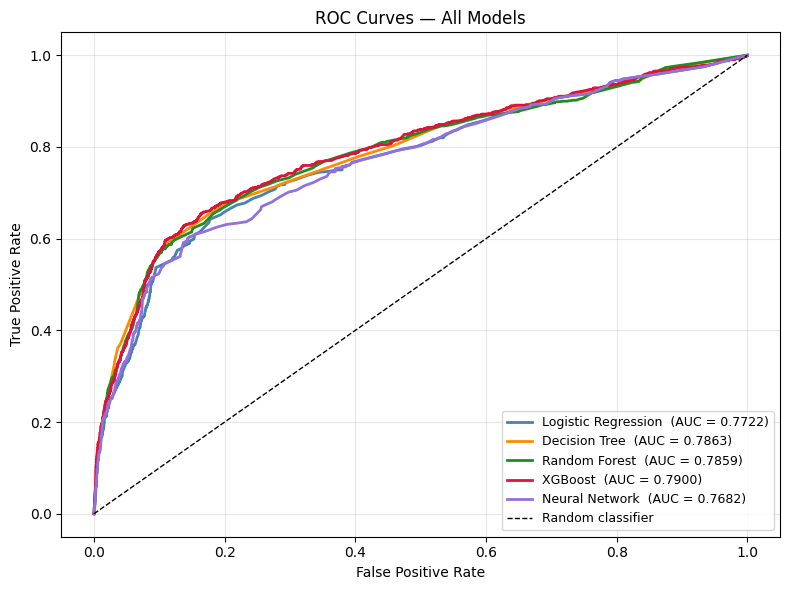

In [16]:
COLORS = ['steelblue', 'darkorange', 'forestgreen', 'crimson', 'mediumpurple']

fig, ax = plt.subplots(figsize=(8, 6))
for (name, r), color in zip(results.items(), COLORS):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, label=f"{name}  (AUC = {r['AUC-ROC']:.4f})", color=color, lw=2)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Confusion Matrices

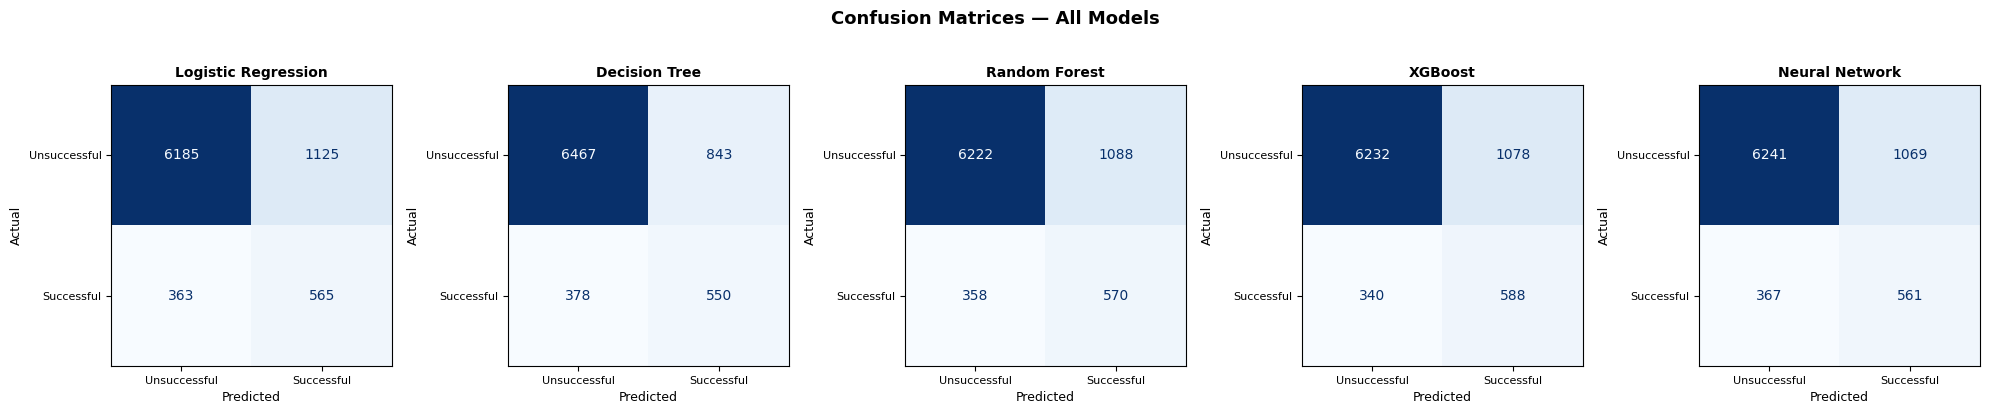

In [17]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))

for ax, (name, r), color in zip(axes, results.items(), COLORS):
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, r['y_pred']),
        display_labels=['Unsuccessful', 'Successful']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)
    ax.tick_params(labelsize=8)

fig.suptitle('Confusion Matrices — All Models', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Metric Comparison Bar Chart

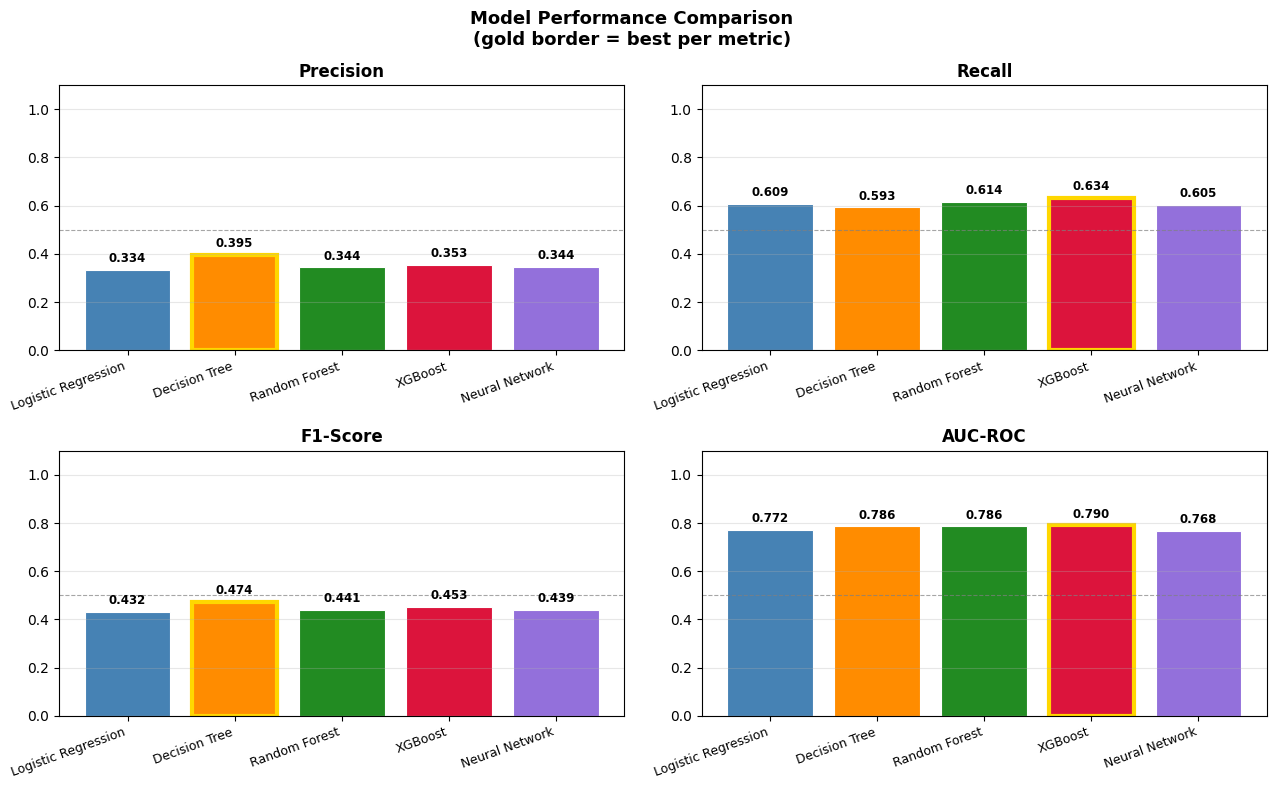

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
model_names = list(results.keys())
x = np.arange(len(model_names))

for ax, metric in zip(axes.flat, METRIC_COLS):
    vals = [results[name][metric] for name in model_names]
    bars = ax.bar(x, vals, color=COLORS, edgecolor='white', linewidth=0.8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold'
        )
    best_idx = int(np.argmax(vals))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

fig.suptitle('Model Performance Comparison\n(gold border = best per metric)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Best Model Recommendation

In [19]:
best_auc = summary['AUC-ROC'].idxmax()
best_f1  = summary['F1-Score'].idxmax()
best_rec = summary['Recall'].idxmax()
best_pre = summary['Precision'].idxmax()

print("\n\n" + "=" * 60)
print("BEST MODEL RECOMMENDATION")
print("=" * 60)
print(f"\n  Best AUC-ROC  : {best_auc:<22} ({summary.loc[best_auc,  'AUC-ROC']:.4f})")
print(f"  Best F1-Score : {best_f1:<22} ({summary.loc[best_f1,  'F1-Score']:.4f})")
print(f"  Best Recall   : {best_rec:<22} ({summary.loc[best_rec, 'Recall']:.4f})")
print(f"  Best Precision: {best_pre:<22} ({summary.loc[best_pre, 'Precision']:.4f})")

print("""
  Context (imbalanced telemarketing data, ~12% positive class):

  • AUC-ROC  is the primary metric — it measures overall discriminative
    ability regardless of decision threshold, ideal for imbalanced classes.

  • Recall   matters most when missing a potential subscriber is costly
    (false negatives = lost revenue).

  • Precision matters when call-centre resources are limited and wasted
    calls are costly (false positives = wasted effort).

  • F1-Score balances both for a single-number comparison.
""")
print(f"  ★  Recommended model: {best_auc}  (highest AUC-ROC)")
print("=" * 60)




BEST MODEL RECOMMENDATION

  Best AUC-ROC  : XGBoost                (0.7900)
  Best F1-Score : Decision Tree          (0.4739)
  Best Recall   : XGBoost                (0.6336)
  Best Precision: Decision Tree          (0.3948)

  Context (imbalanced telemarketing data, ~12% positive class):

  • AUC-ROC  is the primary metric — it measures overall discriminative
    ability regardless of decision threshold, ideal for imbalanced classes.

  • Recall   matters most when missing a potential subscriber is costly
    (false negatives = lost revenue).

  • Precision matters when call-centre resources are limited and wasted
    calls are costly (false positives = wasted effort).

  • F1-Score balances both for a single-number comparison.

  ★  Recommended model: XGBoost  (highest AUC-ROC)
